In [1]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
import torch.nn as nn
from tenacity import retry_unless_exception_type
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy
import sklearn.metrics as skm

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import warnings


warnings.filterwarnings('ignore')
pio.renderers.default = 'svg'

pl.Config.set_tbl_cols(-1)


polars.config.Config

In [2]:
raw_data = pl.read_csv('/Users/yokefeipang/Library/CloudStorage/GoogleDrive-kennethpang7@gmail.com/Other computers/My Mac/Python Lessons/DUDL_PythonCode/FFN/mnist_train_small.csv')

In [3]:
raw_data.head()


6,0,0_duplicated_0,0_duplicated_1,0_duplicated_2,0_duplicated_3,0_duplicated_4,0_duplicated_5,0_duplicated_6,0_duplicated_7,0_duplicated_8,0_duplicated_9,0_duplicated_10,0_duplicated_11,0_duplicated_12,0_duplicated_13,0_duplicated_14,0_duplicated_15,0_duplicated_16,0_duplicated_17,0_duplicated_18,0_duplicated_19,0_duplicated_20,0_duplicated_21,0_duplicated_22,0_duplicated_23,0_duplicated_24,0_duplicated_25,0_duplicated_26,0_duplicated_27,0_duplicated_28,0_duplicated_29,0_duplicated_30,0_duplicated_31,0_duplicated_32,0_duplicated_33,0_duplicated_34,0_duplicated_35,0_duplicated_36,0_duplicated_37,0_duplicated_38,0_duplicated_39,0_duplicated_40,0_duplicated_41,0_duplicated_42,0_duplicated_43,0_duplicated_44,0_duplicated_45,0_duplicated_46,0_duplicated_47,0_duplicated_48,0_duplicated_49,0_duplicated_50,0_duplicated_51,0_duplicated_52,0_duplicated_53,0_duplicated_54,0_duplicated_55,0_duplicated_56,0_duplicated_57,0_duplicated_58,0_duplicated_59,0_duplicated_60,0_duplicated_61,0_duplicated_62,0_duplicated_63,0_duplicated_64,0_duplicated_65,0_duplicated_66,0_duplicated_67,0_duplicated_68,0_duplicated_69,0_duplicated_70,0_duplicated_71,0_duplicated_72,0_duplicated_73,0_duplicated_74,0_duplicated_75,0_duplicated_76,0_duplicated_77,0_duplicated_78,0_duplicated_79,0_duplicated_80,0_duplicated_81,0_duplicated_82,0_duplicated_83,0_duplicated_84,0_duplicated_85,0_duplicated_86,0_duplicated_87,0_duplicated_88,0_duplicated_89,0_duplicated_90,0_duplicated_91,0_duplicated_92,0_duplicated_93,0_duplicated_94,0_duplicated_95,0_duplicated_96,0_duplicated_97,0_duplicated_98,0_duplicated_99,0_duplicated_100,0_duplicated_101,0_duplicated_102,0_duplicated_103,0_duplicated_104,0_duplicated_105,0_duplicated_106,0_duplicated_107,0_duplicated_108,0_duplicated_109,0_duplicated_110,0_duplicated_111,0_duplicated_112,0_duplicated_113,0_duplicated_114,0_duplicated_115,0_duplicated_116,0_duplicated_117,0_duplicated_118,0_duplicated_119,0_duplicated_120,24,67,67_duplicated_0,18,0_duplicated_121,0_duplicated_122,0_duplicated_123,0_duplicated_124,0_duplicated_125,0_duplicated_126,0_duplicated_127,0_duplicated_128,0_duplicated_129,0_duplicated_130,0_duplicated_131,0_duplicated_132,0_duplicated_133,0_duplicated_134,0_duplicated_135,0_duplicated_136,0_duplicated_137,0_duplicated_138,0_duplicated_139,0_duplicated_140,0_duplicated_141,0_duplicated_142,0_duplicated_143,0_duplicated_144,131,252,252_duplicated_0,66,0_duplicated_145,0_duplicated_146,0_duplicated_147,0_duplicated_148,0_duplicated_149,0_duplicated_150,0_duplicated_151,0_duplicated_152,0_duplicated_153,0_duplicated_154,0_duplicated_155,0_duplicated_156,0_duplicated_157,0_duplicated_158,0_duplicated_159,0_duplicated_160,0_duplicated_161,0_duplicated_162,0_duplicated_163,0_duplicated_164,0_duplicated_165,0_duplicated_166,0_duplicated_167,159,250,232,30,32,0_duplicated_168,0_duplicated_169,0_duplicated_170,0_duplicated_171,0_duplicated_172,0_duplicated_173,0_duplicated_174,0_duplicated_175,0_duplicated_176,0_duplicated_177,0_duplicated_178,0_duplicated_179,0_duplicated_180,0_duplicated_181,0_duplicated_182,0_duplicated_183,0_duplicated_184,0_duplicated_185,0_duplicated_186,0_duplicated_187,0_duplicated_188,0_duplicated_189,15,222,252_duplicated_1,108,0_duplicated_190,0_duplicated_191,0_duplicated_192,0_duplicated_193,0_duplicated_194,0_duplicated_195,0_duplicated_196,0_duplicated_197,0_duplicated_198,0_duplicated_199,0_duplicated_200,0_duplicated_201,0_duplicated_202,0_duplicated_203,0_duplicated_204,0_duplicated_205,0_duplicated_206,0_duplicated_207,0_duplicated_208,0_duplicated_209,0_duplicated_210,0_duplicated_211,0_duplicated_212,0_duplicated_213,147,252_duplicated_2,183,5,0_duplicated_214,0_duplicated_215,0_duplicated_216,0_duplicated_217,0_duplicated_218,0_duplicated_219,0_duplicated_220,20,89,89_duplicated_0,73,0_duplicated_221,0_duplicated_222,0_duplicated_223,0_duplicated_224,0_duplicated_225,0_duplicated_226,0_duplicated_227,0_duplicated_228,0_duplicated_229,0_duplicated_230,0_duplicated_231,0_duplicate

In [4]:
# select the features - don't need the label
features = raw_data[:, 1:]

minMax_scaler = MinMaxScaler()

# scale the data
scaled_features = minMax_scaler.fit_transform(features)

In [5]:
# convert to tensors
dataT = torch.tensor(scaled_features).float()


In [6]:
# For an autoencoder, the input is the target, so we pass the tensor twice.
# TensorDataset wraps input tensors and provides a uniform way to access them.
train_dataset = TensorDataset(dataT, dataT)

In [7]:
# create dataloader
batchsize = 32
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batchsize,
    shuffle=True # shuffle indices at the start of each epoch

)

In [8]:
# create class autoencoder network
# create class autoencoder network
class aemodel(nn.Module):
    def __init__(self, input_size, encoder_size, bottleneck_size, activation='relu'):
        super().__init__() # call parent class (nn.Module)

        # activation map
        activation_map = {
            'relu' : nn.ReLU,
            'tanh' : nn.Tanh,
            'sigmoid' : nn.Sigmoid,
            'leakyrelu' : nn.LeakyReLU
        }

        # get the activation class from the dictionary
        act_fn = activation_map.get(activation.lower(), nn.ReLU)

        # create an empty list to store the layers
        layers = [
            # encoder
            nn.Linear(input_size, encoder_size),
            act_fn(), # the activation function
            nn.Linear(encoder_size, bottleneck_size),
            act_fn(), # the activation function

            # decoder layer
            nn.Linear(bottleneck_size, encoder_size),
            act_fn(), # the activation function
            nn.Linear(encoder_size, input_size),
        ]

        # wraps all layers into nn.Sequential
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [9]:
aemodel(activation='relu', input_size=784, encoder_size=392, bottleneck_size=100)

aemodel(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=392, bias=True)
    (1): ReLU()
    (2): Linear(in_features=392, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=392, bias=True)
    (5): ReLU()
    (6): Linear(in_features=392, out_features=784, bias=True)
  )
)

In [10]:
# create aenet
def aenet(
        input_size,
        encoder_size,
        bottleneck_size,
        activation='relu',
        learning_rate=0.01,
        optimizer_type='adam',
        scheduler_step=10,
        scheduler_gamma=0.95,
):
    loss_func = nn.MSELoss()

    # create model
    model = aemodel(
        input_size, encoder_size, bottleneck_size, activation=activation
    )

    # optimizer setup
    optimizers_map = {
        "adam": torch.optim.Adam,
        "sgd": torch.optim.SGD,
        "rmsprop": torch.optim.RMSprop
    }

    optimizer_class = optimizers_map.get(optimizer_type.lower(), torch.optim.Adam)
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)

    # scheduler setup
    scheduler =  torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=scheduler_step,
        gamma=scheduler_gamma
    )

    return model, loss_func, optimizer, scheduler


In [11]:
# train the model
def trainModel(
        input_size,
        encoder_size,
        bottleneck_size,
        numepochs=100,
        train_loader=train_loader
):

    training_progress = pl.DataFrame(
        schema=[
            ('iteration', pl.Int64),
            ('epoch', pl.Int64),
            ('loss', pl.Float64),
        ]
    )

    iteration = 0

    # create autoencoder model
    model, loss_func, optimizer, scheduler = aenet(
        input_size,
        encoder_size,
        bottleneck_size,
        activation='relu',
        learning_rate=0.01,
        optimizer_type='adam',
        scheduler_step=10,
        scheduler_gamma=0.95,
    )

    patience = 15
    best_loss = float('inf')
    no_improve_count = 0
    best_model = None

    for epoch in range(numepochs):
        epoch_train_loss=0
        num_batches = 0

        for inputs, targets in train_loader:
            # forward pass and loss
            yHat = model(inputs)
            loss = loss_func(yHat, targets) # remember inputs and targets are the same

            # backprop
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # append the loss
            epoch_train_loss += loss.item()
            num_batches += 1
            iteration += 1

        avg_train_loss = epoch_train_loss / num_batches

        # new row for the dataframe
        new_row = pl.DataFrame([{
            'iteration' : iteration,
            'epoch' : epoch,
            'loss' : avg_train_loss
        }])

        training_progress = pl.concat([training_progress, new_row])

        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            no_improve_count = 0
            best_model = copy.deepcopy(model.state_dict())
        else:
            no_improve_count += 1

        if no_improve_count >= patience and epoch > 20:
            break

    if best_model is not None:
        model.load_state_dict(best_model)

    return training_progress, model, best_loss

In [12]:
# test the model
training_progress, model, best_loss = trainModel(
    input_size=784,
    encoder_size=394,
    bottleneck_size=100,
    numepochs=100,
    train_loader=train_loader
)

In [13]:
training_progress.sort('loss', descending=False)

iteration,epoch,loss
i64,i64,f64
38750,61,0.030333
47500,75,0.030334
31250,49,0.030345
23125,36,0.030356
48125,76,0.030379
…,…,…
3125,4,0.031406
2500,3,0.031635
1875,2,0.032433


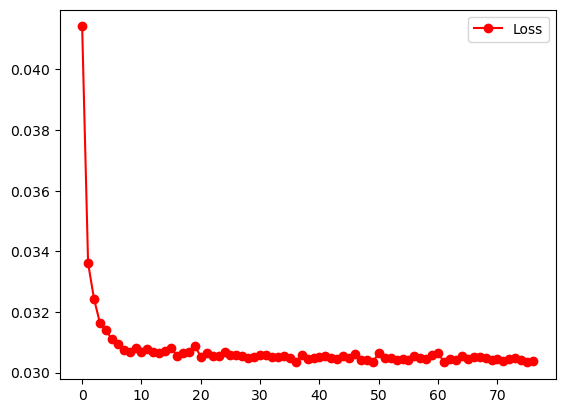

In [14]:
plt.plot(training_progress['epoch'], training_progress['loss'], 'r-o', label='Loss')
plt.legend()

## Run the experiment
* testing for different N units for Encoders and Bottleneck

In [15]:
# specify different number of units
N_encdec_units = np.linspace(10, 500, 10).astype(int)
N_bottle_units = np.linspace(5, 100, 10).astype(int)

In [16]:
all_progress = []

for encdec in N_encdec_units:
    for bottle in N_bottle_units:
        print(f'Training with encoder-decoder units: {encdec} & bottle units: {bottle}')
        training_progress, model, best_loss = trainModel(
            input_size=784,
            encoder_size=encdec,
            bottleneck_size=bottle,
            numepochs=5, # reduce this to 5 because it will take a long time
            train_loader=train_loader
        )

        # annotate the encdec and bottle size
        training_progress = training_progress.with_columns(
            encoder_decoder_units=pl.lit(encdec),
            bottleneck_units=pl.lit(bottle)
        )

        # append dataframe to dataframe list
        all_progress.append(training_progress)

# concatenate all the dataframe
data = pl.concat(all_progress)


Training with encoder-decoder units: 10 & bottle units: 5
Training with encoder-decoder units: 10 & bottle units: 15
Training with encoder-decoder units: 10 & bottle units: 26
Training with encoder-decoder units: 10 & bottle units: 36
Training with encoder-decoder units: 10 & bottle units: 47
Training with encoder-decoder units: 10 & bottle units: 57
Training with encoder-decoder units: 10 & bottle units: 68
Training with encoder-decoder units: 10 & bottle units: 78
Training with encoder-decoder units: 10 & bottle units: 89
Training with encoder-decoder units: 10 & bottle units: 100
Training with encoder-decoder units: 64 & bottle units: 5
Training with encoder-decoder units: 64 & bottle units: 15
Training with encoder-decoder units: 64 & bottle units: 26
Training with encoder-decoder units: 64 & bottle units: 36
Training with encoder-decoder units: 64 & bottle units: 47
Training with encoder-decoder units: 64 & bottle units: 57
Training with encoder-decoder units: 64 & bottle units: 6

In [17]:
# search for the least loss
data.sort(by='loss', descending=False)[0]

iteration,epoch,loss,encoder_decoder_units,bottleneck_units
i64,i64,f64,i32,i32
3125,4,0.023254,118,100


In [18]:
# groupby to get the average performance
average_loss_data = (
    data
    .group_by(['encoder_decoder_units', 'bottleneck_units'])
    .agg(
        pl.col('loss').mean().name.prefix('average_') # actually thinking back it will be best to use min() instead
    )
)

average_loss_data

encoder_decoder_units,bottleneck_units,average_loss
i32,i32,f64
500,36,0.067754
391,5,0.068234
227,47,0.035302
391,26,0.067673
391,100,0.036122
…,…,…
118,57,0.027868
336,100,0.038517
336,26,0.067783


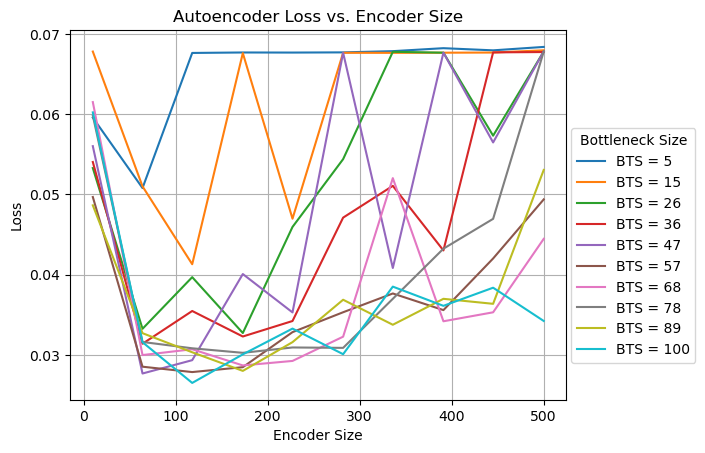

In [66]:
average_loss_data=average_loss_data.sort(['encoder_decoder_units', 'bottleneck_units'], descending=[False, False])

for bts in average_loss_data['bottleneck_units'].unique():
    filtered_data = average_loss_data.filter(pl.col('bottleneck_units') == bts)
    plt.plot(
        filtered_data['encoder_decoder_units'],
        filtered_data['average_loss'],
        label=f'BTS = {bts}',
    )

plt.title('Autoencoder Loss vs. Encoder Size')
plt.xlabel('Encoder Size')
plt.ylabel('Loss')
plt.legend(title='Bottleneck Size', loc=[1.01, 0.1]) # Display the legend
plt.grid(True)
plt.show()

In [19]:
# pivotg
heatmap_data_pd = (
    average_loss_data
    .sort(['encoder_decoder_units', 'bottleneck_units'], descending=[False, False])
    # .sort('average_loss', descending=True)
    .pivot(
        index='bottleneck_units',
        on='encoder_decoder_units',
        values='average_loss'
    ).to_pandas().set_index('bottleneck_units')
)

heatmap_data_pd

,10,64,118,173,227,282,336,391,445,500
bottleneck_units,,,,,,,,,,
5,0.059585,0.050801,0.067641,0.067699,0.067688,0.067712,0.067864,0.068234,0.067965,0.068391
15,0.067814,0.051011,0.041309,0.067617,0.046982,0.067659,0.067653,0.067671,0.067691,0.067970
26,0.053294,0.033261,0.039697,0.032735,0.045957,0.054404,0.067783,0.067673,0.057330,0.067826
36,0.054046,0.031398,0.035479,0.032300,0.034231,0.047116,0.051077,0.043027,0.067711,0.067754
47,0.056024,0.027689,0.029350,0.040084,0.035302,0.067662,0.040839,0.067679,0.056485,0.067832
57,0.049684,0.028537,0.027868,0.028477,0.032844,0.035323,0.037662,0.035591,0.042024,0.049388
68,0.061515,0.029988,0.030711,0.028694,0.029255,0.032278,0.052038,0.034198,0.035316,0.044472
78,0.059835,0.031619,0.030831,0.030266,0.030934,0.030884,0.036997,0.043245,0.046962,0.067811
89,0.048650,0.032714,0.030335,0.028014,0.031597,0.036881,0.033764,0.036997,0.036374,0.053061


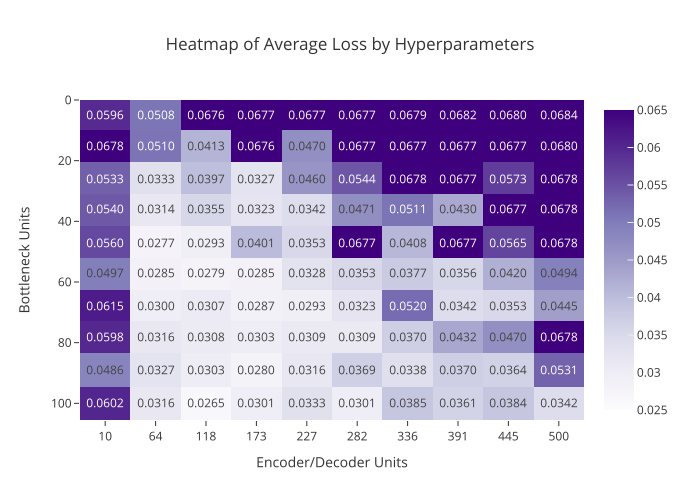

In [24]:
fig = px.imshow(
    heatmap_data_pd,
    text_auto='.4f',
    aspect='auto',
    title='Heatmap of Average Loss by Hyperparameters',
    zmax=0.065,
    zmin=0.025,
    color_continuous_scale='Purples',
)

fig.update_layout(template='ggplot2', xaxis_title="Encoder/Decoder Units", yaxis_title="Bottleneck Units", height=500)

In [25]:
print(average_loss_data['average_loss'].min())
print(average_loss_data['average_loss'].max())

0.026514838706851007
0.06839110695719719


## Optuna Hyperparameters Optimization

For example:
   * encoder_size
   * bottleneck_size
   * numepochs


In [26]:
data.head(2)

iteration,epoch,loss,encoder_decoder_units,bottleneck_units
i64,i64,f64,i32,i32
625,0,0.0626,10,5
1250,1,0.059611,10,5


In [27]:
def objective(trial):
    # suggest hyperparameters
    encoder_size = trial.suggest_int('encoder_size', 10, 500, step=5)
    bottleneck_size = trial.suggest_int('bottleneck_size', 5, 100, step=5)
    numepochs = trial.suggest_int('numepochs', 5, 500, 10)

    try:
        # convert to tensors
        dataT = torch.tensor(scaled_features).float()

        # For an autoencoder, the input is the target, so we pass the tensor twice.
        train_dataset = TensorDataset(dataT, dataT)
        # create dataloader
        batchsize = 32

        train_loader = DataLoader(
            dataset=train_dataset,
            batch_size=batchsize,
            shuffle=True  # shuffle indices at the start of each epoch
        )

        training_progress, model, best_loss = trainModel(
            input_size=784,
            encoder_size=encoder_size,
            bottleneck_size=bottleneck_size,
            numepochs=numepochs,
            train_loader=train_loader
        )

        return best_loss

    except Exception as e:
        print(f"Trial failed: {e}")
        return float('inf')

In [28]:
# crate and run optuna study
study = optuna.create_study(
    direction='minimize',
    study_name='Test',
    sampler=optuna.samplers.TPESampler(seed=42)
)

# Run optimization
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"Best validation loss: {study.best_value:.4f}")

print("Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-12 20:29:47,532] A new study created in memory with name: Test


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-11-12 20:30:36,771] Trial 0 finished with value: 0.02733084230720997 and parameters: {'encoder_size': 195, 'bottleneck_size': 100, 'numepochs': 365}. Best is trial 0 with value: 0.02733084230720997.
[I 2025-11-12 20:31:28,160] Trial 1 finished with value: 0.04154674534201622 and parameters: {'encoder_size': 305, 'bottleneck_size': 20, 'numepochs': 75}. Best is trial 0 with value: 0.02733084230720997.
[I 2025-11-12 20:31:52,745] Trial 2 finished with value: 0.03169804712533951 and parameters: {'encoder_size': 35, 'bottleneck_size': 90, 'numepochs': 305}. Best is trial 0 with value: 0.02733084230720997.
[I 2025-11-12 20:32:13,731] Trial 3 finished with value: 0.06748333245515824 and parameters: {'encoder_size': 360, 'bottleneck_size': 5, 'numepochs': 485}. Best is trial 0 with value: 0.02733084230720997.
[I 2025-11-12 20:32:40,292] Trial 4 finished with value: 0.06748363536000251 and parameters: {'encoder_size': 420, 'bottleneck_size': 25, 'numepochs': 95}. Best is trial 0 with v

In [29]:
# Create results DataFrame
trials_data = []

for trial in study.trials:
    if trial.value is not None:
        trial_info = {
            'trial_number': trial.number,
            'loss': trial.value,
            **trial.params
        }
        trials_data.append(trial_info)

results_df = pl.DataFrame(trials_data)

results_df.sort('loss', descending=False)

trial_number,loss,encoder_size,bottleneck_size,numepochs
i64,f64,i64,i64,i64
11,0.021478,140,100,435
19,0.023805,90,65,495
10,0.024844,150,70,425
18,0.025438,180,90,435
24,0.025527,140,50,355
…,…,…,…,…
1,0.041547,305,20,75
23,0.053256,10,90,495
3,0.067483,360,5,485


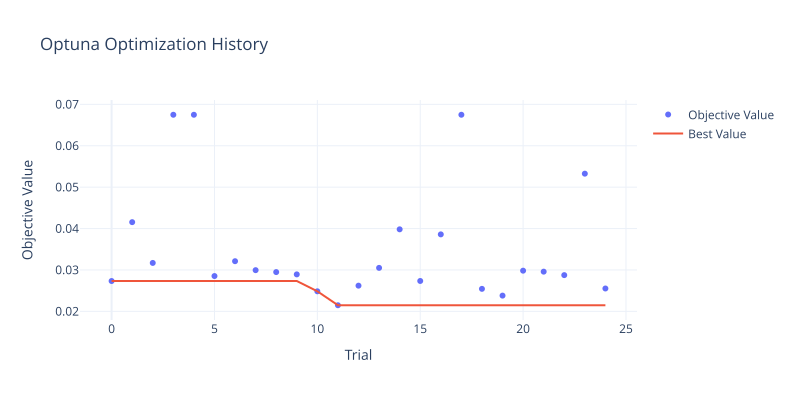

In [30]:
# Visualization: Optimization history
fig1 = plot_optimization_history(study)
fig1.update_layout(
    title="Optuna Optimization History",
    template='plotly_white',
    width=800,
    height=400
)
fig1.show()

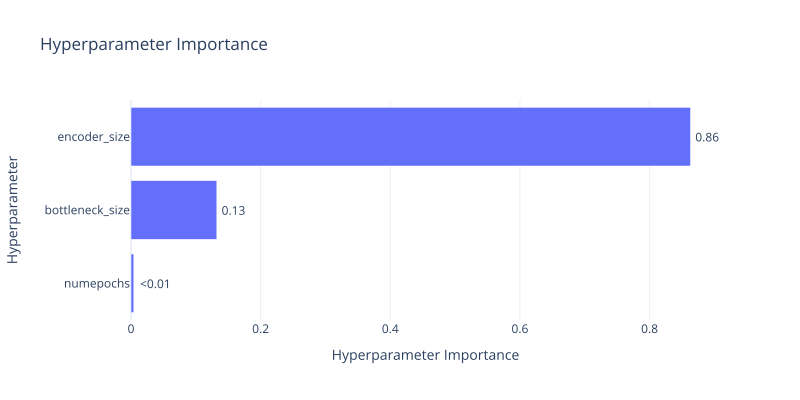

In [31]:
# Visualization: Parameter importance
fig2 = plot_param_importances(study)
fig2.update_layout(
    title="Hyperparameter Importance",
    template='plotly_white',
    width=800,
    height=400
)
fig2.show()

In [37]:
results_df = results_df.sort(['encoder_size', 'bottleneck_size'], descending=[False, False])

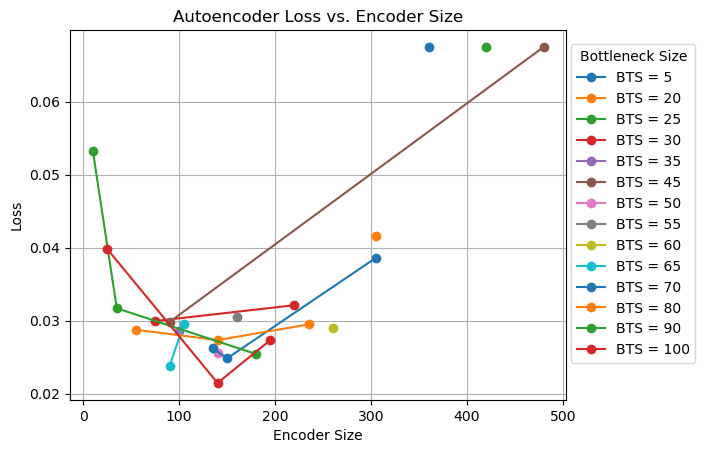

In [62]:
for bts in results_df['bottleneck_size'].unique():
    filtered_data = results_df.filter(pl.col('bottleneck_size') == bts)
    plt.plot(
        filtered_data['encoder_size'],
        filtered_data['loss'],
        marker='o',
        label=f'BTS = {bts}',
    )

plt.title('Autoencoder Loss vs. Encoder Size')
plt.xlabel('Encoder Size')
plt.ylabel('Loss')
plt.legend(title='Bottleneck Size', loc=[1.01, 0.1]) # Display the legend
plt.grid(True)
plt.show()

In [68]:
# !jupyter nbconvert --to html autoenc_codeChallenge_Nunits_polars.ipynb

[NbConvertApp] Converting notebook autoenc_codeChallenge_Nunits_polars.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 780129 bytes to autoenc_codeChallenge_Nunits_polars.html
